# Entrega 2 — Predicción de Precios de Autos Usados en Chile
**Universidad Diego Portales | Data Science | Profesor: Andrés Jiménez**

Correcciones respecto a Entrega 1
1. **Multicolinealidad Año/Km**: Se reemplaza `Año` por `antigüedad_auto = 2026 - Año`.
2. **R² bajo y sin comparación Train/Test**: Se reporta R² train vs test para detectar overfitting.
3. **Clasificación circular**: Ya NO se usan residuos del modelo para clasificar. Se extraen 15 autos de demostración *antes* del entrenamiento y se compara su precio publicado contra el precio predicho por el modelo.
4. **Un solo modelo**: Se selecciona XGBoost como modelo principal, evaluado con GridSearchCV y KFold CV (k=5), comparado contra un Baseline de referencia.

## 0. Setup e Importaciones

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("✓ XGBoost disponible:", xgb.__version__)
except ImportError:
    XGB_AVAILABLE = False
    print("⚠ XGBoost no instalado — se usará GradientBoosting de sklearn")

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
print("Setup completo ✓")

Mounted at /content/drive
✓ XGBoost disponible: 3.2.0
Setup completo ✓


## 1. Carga y Limpieza de Datos

### Integrante 2 — Data Engineer: Pipeline de Preprocesamiento v2.0

**Mejoras respecto a Presentación 1:**
- Pipeline automatizado en funciones reutilizables
- Dataset ampliado de 1,000 a **34,502 registros** (7 fuentes scrapeadas)
- Feature Engineering: `antigüedad_auto` reemplaza `Año` (corrige multicolinealidad)
- Funciones de limpieza extendidas para soportar datos multi-fuente (inglés/español)

**Resultado:** 34,502 → **32,371 registros limpios** (reducción del 6.2%)

In [2]:
# ── Rutas ──────────────────────────────────────────────────────────────────
BASE           = Path('/content/drive/MyDrive/')
PATH_COMBINADO = BASE / 'datos_combinados_entrega2.csv'

# ── Cargar datos ───────────────────────────────────────────────────────────
df_comb = pd.read_csv(PATH_COMBINADO)
print(f'Dataset combinado: {df_comb.shape}')

Dataset combinado: (34502, 8)


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# Funciones de limpieza — inspiradas en Entrega 1
# Extendidas para soportar el dataset multi-fuente de Entrega 2
# ══════════════════════════════════════════════════════════════════════════

def limpiar_combustible(valor):
    """Igual que Entrega 1: detección por substring, no por mapping exacto."""
    if pd.isna(valor):
        return np.nan
    valor = str(valor).lower()
    if 'diesel' in valor or 'petróleo' in valor or 'petroleo' in valor:
        return 'Diesel'
    elif 'bencina' in valor or 'gasolina' in valor or 'gasoline' in valor or 'petrol' in valor:
        return 'Bencina'
    elif 'híbrido' in valor or 'hibrido' in valor or 'hybrid' in valor:
        return 'Híbrido'
    elif 'eléctrico' in valor or 'electrico' in valor or 'electric' in valor:
        return 'Eléctrico'
    elif 'gas' in valor:
        return 'Gas'
    else:
        return 'Otro'


def limpiar_transmision(valor):
    """Igual que Entrega 1: 'M' o 'manual' → Manual, 'auto*' → Automática."""
    if pd.isna(valor):
        return np.nan
    valor = str(valor).lower().strip()
    if valor in ['m', 'manual', 'mecánica', 'mecanica', 'mechanical']:
        return 'Manual'
    elif 'auto' in valor or 'cvt' in valor or 'tiptronic' in valor or 'dsg' in valor:
        return 'Automática'
    else:
        return np.nan


def eliminar_outliers_iqr(df, columna):
    """IQR idéntico al de Entrega 1."""
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    antes = len(df)
    df_out = df[(df[columna] >= lim_inf) & (df[columna] <= lim_sup)].copy()
    print(f'  {columna}: {antes - len(df_out)} outliers eliminados '
          f'(lím inf={lim_inf:,.0f} | lím sup={lim_sup:,.0f})')
    return df_out


def clean_dataset(df_raw, source_name='datos', apply_iqr=True):
    """
    Pipeline de limpieza inspirado en Entrega 1, extendido para multi-fuente.
    Pasos:
      1. Normalizar nombres de columnas (inglés → español)
      2. Filtrar solo autos (excluir camiones, motos, maquinaria)
      3. Limpiar Combustible y Transmisión con las mismas funciones de Entrega 1
      4. Imputar nulos con moda (igual que Entrega 1)
      5. Outliers con IQR en price y Kilometraje
      6. Validación de coherencia (price > 500K, año ∈ [1990,2026], km > 0)
      7. Feature engineering: antigüedad_auto, km_por_año, price_log
    """
    df = df_raw.copy()

    # 1. Normalizar nombres de columnas
    col_map = {
        'make': 'Marca', 'model': 'Modelo', 'year': 'Ano',
        'km': 'Kilometraje', 'price_clp': 'price',
        'fuel_type': 'Combustible', 'transmission': 'Transmision',
        'body_type': 'Category', 'seller_type': 'Tipo_de_vendedor',
        'region': 'location',
    }
    df.rename(columns={k: v for k, v in col_map.items() if k in df.columns}, inplace=True)

    # Convertir tipos numéricos
    for col in ['Ano', 'Kilometraje', 'price']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 2. Filtrar por categoría si existe (igual que Entrega 1)
    if 'Category' in df.columns:
        categorias_auto = [
            'Autos-vehículo', 'Autos, camionetas y 4x4', 'Autos, Camionetas y 4x4',
            'Sedán', 'Sedan', 'SUV', 'Station Wagon', 'Pick Up',
            'sedan', 'suv', 'hatchback', 'station wagon', 'pickup',
            'coupe', 'convertible', 'minivan',
        ]
        mascara_auto = df['Category'].str.lower().isin([c.lower() for c in categorias_auto])
        df = df[mascara_auto | df['Category'].isna()].copy()

    n0 = len(df)

    # 3. Limpiar Combustible y Transmisión
    if 'Combustible' in df.columns:
        df['Combustible'] = df['Combustible'].apply(limpiar_combustible)
    if 'Transmision' in df.columns:
        df['Transmision'] = df['Transmision'].apply(limpiar_transmision)

    # 4. Imputar nulos con moda (igual que Entrega 1)
    for col in ['Combustible', 'Transmision']:
        if col in df.columns and df[col].isna().any():
            moda = df[col].mode()
            if len(moda) > 0:
                df[col] = df[col].fillna(moda[0])

    # Eliminar filas sin datos clave
    df = df.dropna(subset=['Marca', 'Modelo', 'Ano', 'Kilometraje', 'price'])

    # 5. Outliers con IQR (igual que Entrega 1)
    if apply_iqr:
        print(f'[{source_name}] Outliers IQR:')
        df = eliminar_outliers_iqr(df, 'price')
        df = eliminar_outliers_iqr(df, 'Kilometraje')

    # 6. Validación de coherencia (igual que Entrega 1)
    antes = len(df)
    df = df[df['price'] > 500_000]
    df = df[(df['Ano'] >= 1990) & (df['Ano'] <= 2026)]
    df = df[df['Kilometraje'] > 0]
    print(f'[{source_name}] Coherencia: {antes - len(df)} registros eliminados')
    print(f'[{source_name}] {n0} → {len(df)} registros finales')

    # 7. Feature Engineering (nuevo en Entrega 2)
    df['antigüedad_auto'] = 2026 - df['Ano']
    df['km_por_año']      = (df['Kilometraje'] / df['antigüedad_auto'].replace(0, 1)).round(0)
    df['Marca']  = df['Marca'].str.strip().str.title()
    df['Modelo'] = df['Modelo'].str.strip().str.title()
    df['price_log'] = np.log1p(df['price'])

    return df.reset_index(drop=True)


# ── Aplicar limpieza al dataset combinado (Entrega 2) ──────────────────────
print('=' * 55)
print('DATASET COMBINADO (Entrega 2 — multi-fuente)')
print('=' * 55)
df_comb_clean = clean_dataset(df_comb, 'combinado', apply_iqr=True)

print()
print(f'Resumen: {len(df_comb_clean):,} registros limpios')
print()
df_comb_clean[['Marca','Modelo','antigüedad_auto','Kilometraje','Combustible','Transmision','price']].head(5)

DATASET COMBINADO (Entrega 2 — multi-fuente)
[combinado] Outliers IQR:
  price: 1622 outliers eliminados (lím inf=-5,600,000 | lím sup=24,000,000)
  Kilometraje: 502 outliers eliminados (lím inf=-112,690 | lím sup=337,241)
[combinado] Coherencia: 7 registros eliminados
[combinado] 34502 → 32371 registros finales

Resumen: 32,371 registros limpios



,Marca,Modelo,antigüedad_auto,Kilometraje,Combustible,Transmision,price
0,Peugeot,208,5.0,45000.0,Bencina,Manual,8490000.0
1,Citroen,C3,9.0,120000.0,Diesel,Manual,6490000.0
2,Mg,Mg 5,2.0,9000.0,Bencina,Manual,8890000.0
3,Nissan,Kicks,9.0,100000.0,Bencina,Manual,8950000.0
4,Dodge,Journey,8.0,97000.0,Bencina,Automática,9290000.0


## 2. Separación de Datos de Validación y Autos de Demostración

**CORRECCIONES METODOLÓGICAS** realizadas antes de entrenar el modelo:

1. **Autos Chileautos** (~600 registros): fuente externa separada del conjunto de entrenamiento. Se usan *después* del entrenamiento para calibrar los **umbrales de clasificación** (P25/P75) de forma empírica, sin circularidad.
2. **15 autos demo**: extraídos del dataset restante para la presentación. El modelo nunca los ve.

> Dataset principal: **32,371 registros limpios** de 7 fuentes scrapeadas.

In [4]:
df_main = df_comb_clean.copy()
print(f'Dataset total limpio: {len(df_main):,} registros')

# ── 1. Separar Chileautos ANTES de entrenar ─────────────────────────────
if 'source' in df_main.columns:
    df_chileautos = df_main[df_main['source'] == 'chileautos_original'].copy().reset_index(drop=True)
    df_sin_chile  = df_main[df_main['source'] != 'chileautos_original'].copy()
    print(f'Chileautos separados (validacion umbral): {len(df_chileautos):,} registros')
    print(f'Dataset sin Chileautos: {len(df_sin_chile):,} registros')
else:
    df_chileautos = pd.DataFrame()
    df_sin_chile  = df_main.copy()
    print('Columna source no encontrada — se usara todo el dataset para entrenar')

# ── 2. Extraer 15 autos demo de fuentes distintas a Yapo ─────────────────
# Yapo representa el 95% del dataset — los demos son más interesantes
# si provienen de fuentes con precios distintos (kavak, autocosmos, etc.)
df_sin_chile = df_sin_chile.reset_index(drop=True)

if 'source' in df_sin_chile.columns:
    df_no_yapo = df_sin_chile[df_sin_chile['source'] != 'yapo'].copy()
    print(f'\nFuentes disponibles para demo (sin Yapo): {df_no_yapo["source"].value_counts().to_dict()}')
else:
    df_no_yapo = df_sin_chile.copy()

np.random.seed(42)
terciles = pd.qcut(df_no_yapo['price'], q=3, labels=['bajo', 'medio', 'alto'])
df_no_yapo = df_no_yapo.copy()
df_no_yapo['_tercil'] = terciles

demo_idx = []
for t in ['bajo', 'medio', 'alto']:
    sub = df_no_yapo[df_no_yapo['_tercil'] == t]
    demo_idx.extend(sub.sample(n=min(5, len(sub)), random_state=42).index.tolist())

df_demo  = df_sin_chile.loc[demo_idx].copy().reset_index(drop=True)
df_model = df_sin_chile.drop(index=demo_idx).drop(
    columns=[c for c in ['_tercil'] if c in df_sin_chile.columns]
).reset_index(drop=True)

print(f'\nResumen de conjuntos:')
print(f'  Chileautos (umbral)  : {len(df_chileautos):,}')
print(f'  Demo (presentacion)  : {len(df_demo)} — fuentes: {df_demo["source"].value_counts().to_dict() if "source" in df_demo.columns else "N/A"}')
print(f'  Entrenamiento/test   : {len(df_model):,}')
print()
df_demo[['Marca', 'Modelo', 'Ano', 'Kilometraje', 'Combustible', 'Transmision', 'price']]\
    .style.format({'price': '${:,.0f}', 'Kilometraje': '{:,.0f}'})

Dataset total limpio: 32,371 registros
Chileautos separados (validacion umbral): 604 registros
Dataset sin Chileautos: 31,767 registros

Fuentes disponibles para demo (sin Yapo): {'auto_cl': 252, 'autocosmos.cl': 252, 'autosusados': 212, 'kavak': 96, 'autopia': 96}

Resumen de conjuntos:
  Chileautos (umbral)  : 604
  Demo (presentacion)  : 15 — fuentes: {'autocosmos.cl': 4, 'auto_cl': 4, 'autopia': 3, 'kavak': 2, 'autosusados': 2}
  Entrenamiento/test   : 31,752



,Marca,Modelo,Ano,Kilometraje,Combustible,Transmision,price
0,Chevrolet,S/Modelo,2014.000000,"150,000",Bencina,Manual,"$3,300,000"
1,Nissan,X-Trail,2010.000000,"161,000",Bencina,Automática,"$6,200,000"
2,Renault,Kwid,2024.000000,"52,837",Bencina,Manual,"$7,590,000"
3,Kia,Morning,2017.000000,"65,500",Bencina,Manual,"$6,000,000"
4,Mg,Mg 3,2023.000000,"52,826",Bencina,Manual,"$7,990,000"
5,Honda,Hr-V,2018.000000,"105,000",Bencina,Automática,"$10,101,900"
6,Suzuki,Baleno,2024.000000,"58,663",Bencina,Manual,"$11,290,000"
7,Mg,Zx,2023.000000,"16,318",Bencina,Automática,"$10,980,000"
8,Jeep,Renegade,2022.000000,"52,800",Bencina,Manual,"$11,000,000"
9,Toyota,Yaris,2019.000000,"68,744",Bencina,Automática,"$9,890,000"


# INTEGRANTE 3 - Data Analyst

# VALIDACIÓN DE LA TRANSFORMACIÓN LOGARÍTMICA DEL PRECIO

Cálculo de skewness y generación de histogramas y Q-Q plots para comparar la distribución del precio bruto vs log(precio).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = df_main.copy()

y = df["price"]
y_log = np.log1p(y)

print("Skewness precio bruto:", y.skew())
print("Skewness log(precio):", y_log.skew())

Skewness precio bruto: 0.7674836821930366
Skewness log(precio): -0.5430875651225651


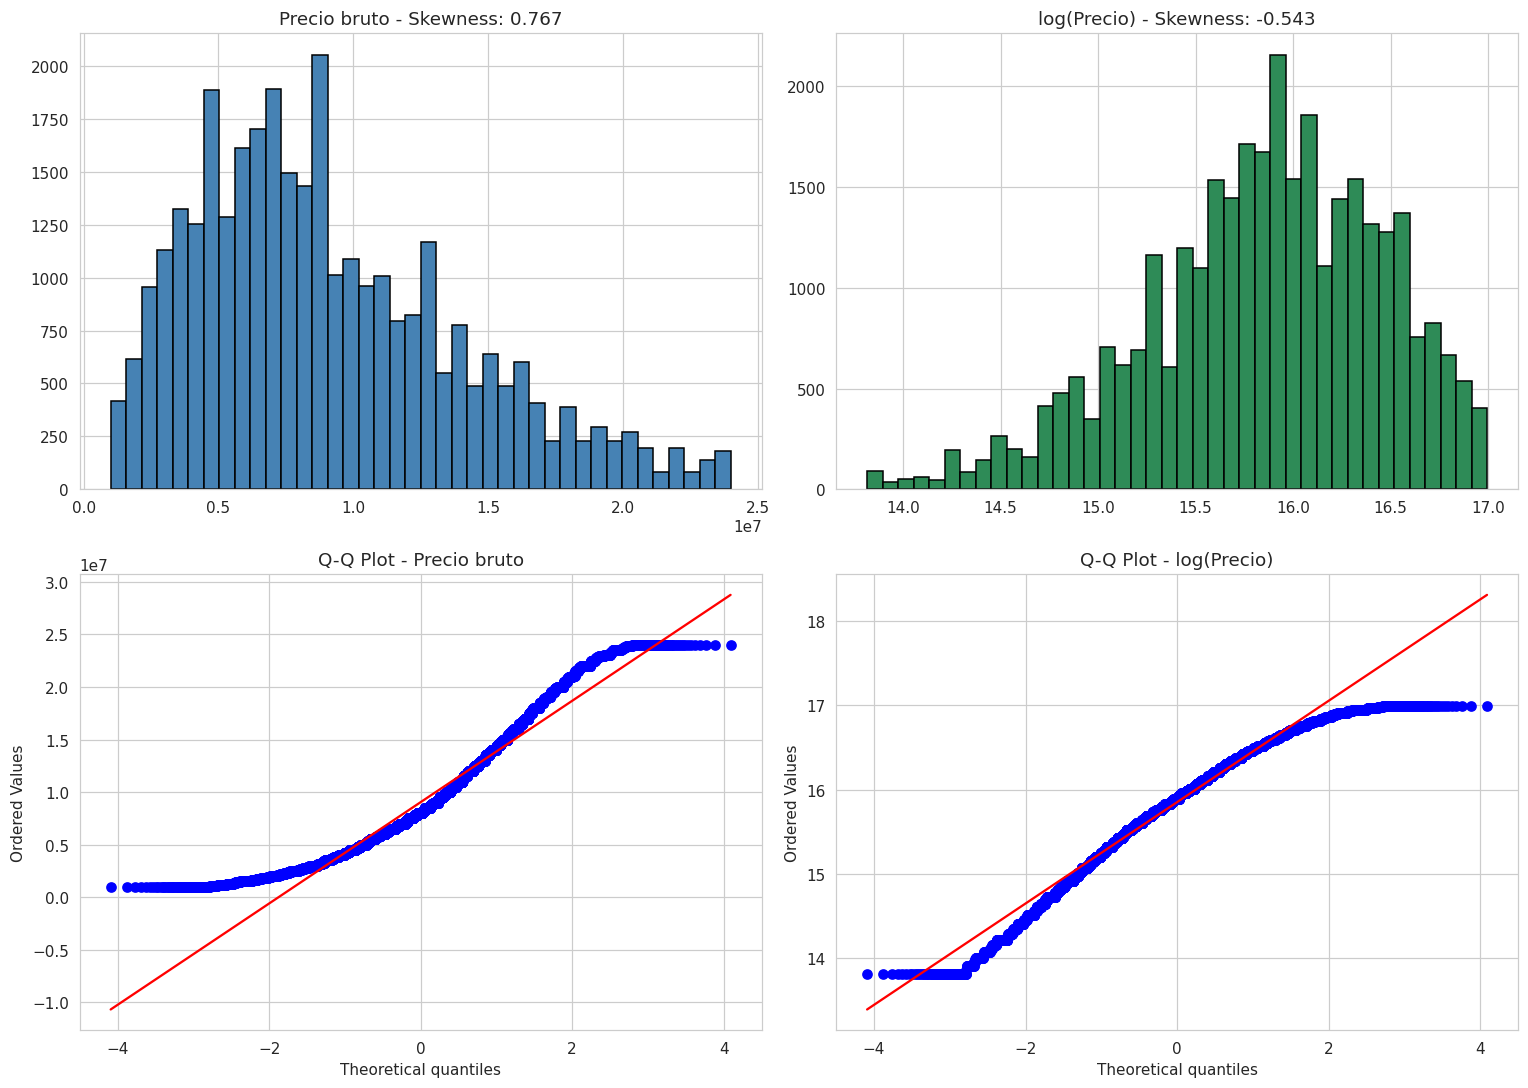

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(y, bins=40, color='steelblue', edgecolor='black')
axes[0, 0].set_title(f'Precio bruto - Skewness: {y.skew():.3f}')

axes[0, 1].hist(y_log, bins=40, color='seagreen', edgecolor='black')
axes[0, 1].set_title(f'log(Precio) - Skewness: {y_log.skew():.3f}')

stats.probplot(y, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Precio bruto')

stats.probplot(y_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot - log(Precio)')

plt.tight_layout()
plt.show()

# MATRIZ DE CORRELACIÓN DE PEARSON

Matriz de correlación de Pearson para detectar multicolinealidad entre variables numéricas.

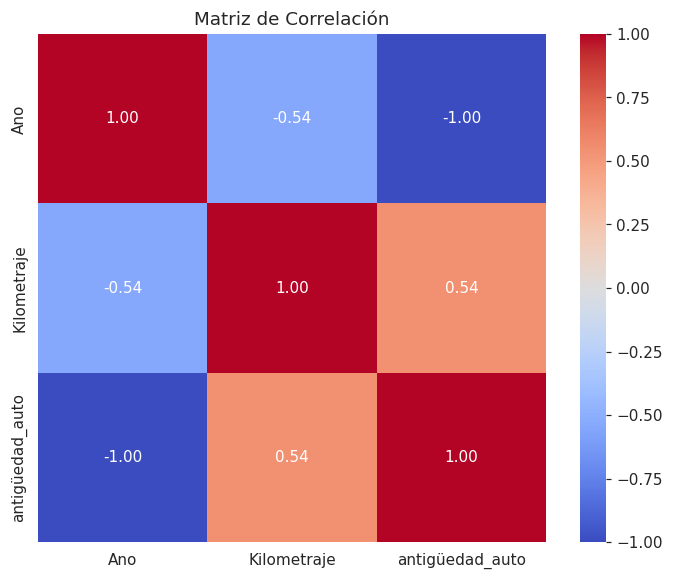

In [7]:
import seaborn as sns

numeric_vars = ['Ano', 'Kilometraje', 'antigüedad_auto']
correlation_matrix = df[numeric_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matriz de Correlación')
plt.show()

# CÁLCULO DEL VIF (VARIANCE INFLATION FACTOR)

Cálculo del Variance Inflation Factor para cuantificar la multicolinealidad. Se excluye la variable 'Ano' por su alta correlación con 'antiguedad_auto'.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[numeric_vars].dropna()
X_vif = X_vif.drop(columns=['Ano'])

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

          Variable       VIF
0      Kilometraje  4.243044
1  antigüedad_auto  4.243044


# ANÁLISIS DE PRECIO POR VARIABLES CATEGÓRICAS

Estadísticas descriptivas de precio agrupadas por tipo de combustible y tipo de transmisión.

In [9]:
df.groupby('Combustible')['price'].agg(['count', 'mean', 'median']).round(0)

,count,mean,median
Combustible,,,
Bencina,24384,8368296.0,7500000.0
Diesel,7803,11066375.0,10500000.0
Eléctrico,19,15754205.0,14980000.0
Gas,67,10232537.0,8000000.0
Híbrido,61,14829062.0,16190900.0
Otro,37,9395676.0,9000000.0


In [10]:
df.groupby('Transmision')['price'].agg(['count', 'mean', 'median']).round(0)

,count,mean,median
Transmision,,,
Automática,9767,11469291.0,10990000.0
Manual,22604,7990621.0,7200000.0


# TOP MARCAS POR PRECIO PROMEDIO

Top 10 marcas con mayor precio promedio en el dataset.

In [11]:
top_precio = df.groupby('Marca')['price'].mean().sort_values(ascending=False).head(10)
top_precio

,price
Marca,
Cupra,2.239667e+07
Pontiac,2.200000e+07
Range Rover,1.860000e+07
Jaecoo,1.826500e+07
International,1.775000e+07
Mercedes-Benz,1.709333e+07
Gac,1.699000e+07
Maserati,1.699000e+07
Lynk & Co,1.649000e+07


In [12]:
top_precio = df.groupby('Marca')['price'].agg(['count', 'mean']).round(0)
top_precio = top_precio.sort_values('mean', ascending=False).head(10)
top_precio

,count,mean
Marca,,
Cupra,3,22396667.0
Pontiac,1,22000000.0
Range Rover,2,18600000.0
Jaecoo,16,18265000.0
International,2,17750000.0
Mercedes-Benz,9,17093333.0
Gac,1,16990000.0
Maserati,1,16990000.0
Lynk & Co,1,16490000.0


# BOXPLOTS POR COMBUSTIBLE Y TRANSMISIÓN

Boxplots para visualizar la distribución del precio según tipo de combustible y tipo de transmisión.

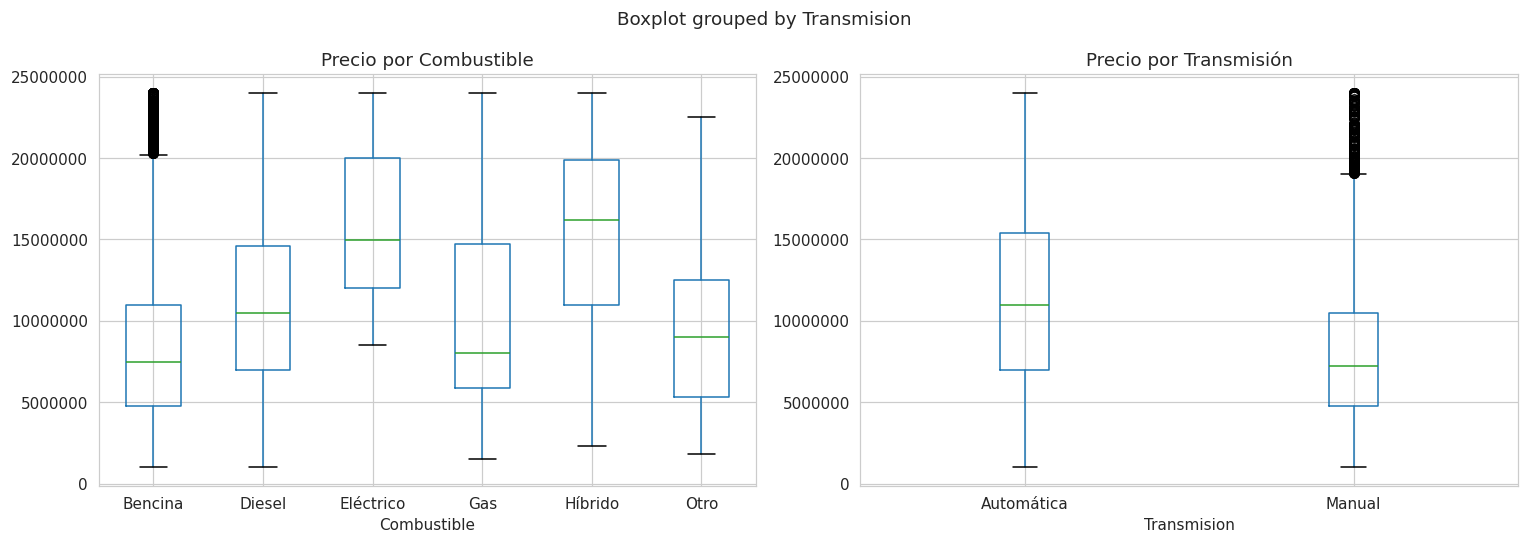

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='price', by='Combustible', ax=axes[0])
axes[0].set_title('Precio por Combustible')
axes[0].ticklabel_format(style='plain', axis='y')

df.boxplot(column='price', by='Transmision', ax=axes[1])
axes[1].set_title('Precio por Transmisión')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# RELACIÓN PRECIO VS ANTIGÜEDAD

Gráfico de dispersión y línea de tendencia entre precio y antigüedad del vehículo.

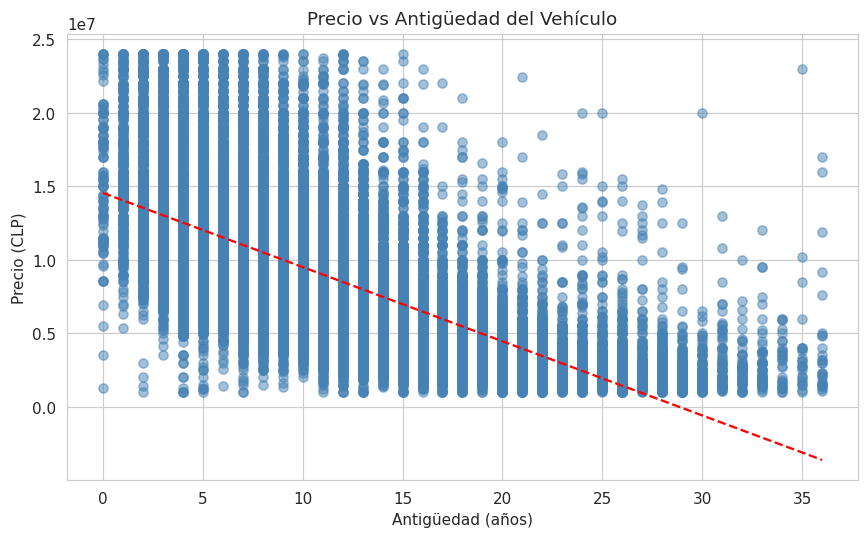

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['antigüedad_auto'], df['price'], alpha=0.5, color='steelblue')
plt.xlabel('Antigüedad (años)')
plt.ylabel('Precio (CLP)')
plt.title('Precio vs Antigüedad del Vehículo')
z = np.polyfit(df['antigüedad_auto'], df['price'], 1)
p = np.poly1d(z)
plt.plot(df['antigüedad_auto'].sort_values(), p(df['antigüedad_auto'].sort_values()), "r--")
plt.tight_layout()
plt.show()

## 3. Preparación de Features y Split Train/Test

In [15]:
def target_encode_fit(series, target):
    global_mean = target.mean()
    mapping = target.groupby(series).mean().to_dict()
    return mapping, global_mean

def target_encode_transform(series, mapping, global_mean):
    return series.map(mapping).fillna(global_mean)

# ── Features ───────────────────────────────────────────────────────────────
NUM_FEATURES = ['antigüedad_auto', 'Kilometraje']
CAT_OHE      = ['Combustible', 'Transmision']
CAT_TARGET   = ['Marca', 'Modelo']
TARGET       = 'price_log'
TARGET_ORIG  = 'price'

# ── Split 80/20 estratificado por precio ──────────────────────────────────
X      = df_model[NUM_FEATURES + CAT_OHE + CAT_TARGET + [TARGET_ORIG]].copy()
y_log  = df_model[TARGET]
y_orig = df_model[TARGET_ORIG]

price_bins = pd.qcut(y_orig, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42, stratify=price_bins
)
y_train_orig = np.expm1(y_train)
y_test_orig  = np.expm1(y_test)

print(f'Train: {len(X_train):,} autos | Test: {len(X_test):,} autos')
print(f'Precio train — mediana: ${y_train_orig.median():,.0f} | media: ${y_train_orig.mean():,.0f}')
print(f'Precio test  — mediana: ${y_test_orig.median():,.0f}  | media: ${y_test_orig.mean():,.0f}')

# ── Target encoding SOLO en train (sin data leakage) ─────────────────────
te_maps, te_globals = {}, {}
for col in CAT_TARGET:
    te_maps[col], te_globals[col] = target_encode_fit(X_train[col], y_train)

# ── OHE fit en train, aplicar a test ─────────────────────────────────────
ohe_train = pd.get_dummies(X_train[CAT_OHE], prefix=CAT_OHE, drop_first=True)
ohe_test  = pd.get_dummies(X_test[CAT_OHE],  prefix=CAT_OHE, drop_first=True)
ohe_test  = ohe_test.reindex(columns=ohe_train.columns, fill_value=0)

def build_encoded(X_split, ohe_df):
    num = X_split[NUM_FEATURES].reset_index(drop=True)
    te  = pd.DataFrame({
        f'{c}_te': target_encode_transform(X_split[c], te_maps[c], te_globals[c])
        for c in CAT_TARGET
    }).reset_index(drop=True)
    return pd.concat([num, te, ohe_df.reset_index(drop=True)], axis=1)

X_train_enc = build_encoded(X_train, ohe_train)
X_test_enc  = build_encoded(X_test,  ohe_test)

print(f'\nFeatures del modelo: {list(X_train_enc.columns)}')
print(f'Shape train: {X_train_enc.shape} | test: {X_test_enc.shape}')

Train: 25,401 autos | Test: 6,351 autos
Precio train — mediana: $8,000,000 | media: $8,983,280
Precio test  — mediana: $7,990,000  | media: $8,977,252

Features del modelo: ['antigüedad_auto', 'Kilometraje', 'Marca_te', 'Modelo_te', 'Combustible_Diesel', 'Combustible_Eléctrico', 'Combustible_Gas', 'Combustible_Híbrido', 'Combustible_Otro', 'Transmision_Manual']
Shape train: (25401, 10) | test: (6351, 10)


### 3.1 Correlación entre Features del Modelo

Verificamos que ningún par de features tenga correlación excesivamente alta (|r| > 0.8), lo que indicaría multicolinealidad problemática.

[3.1] Matriz de correlación — todas las features del modelo (train set)


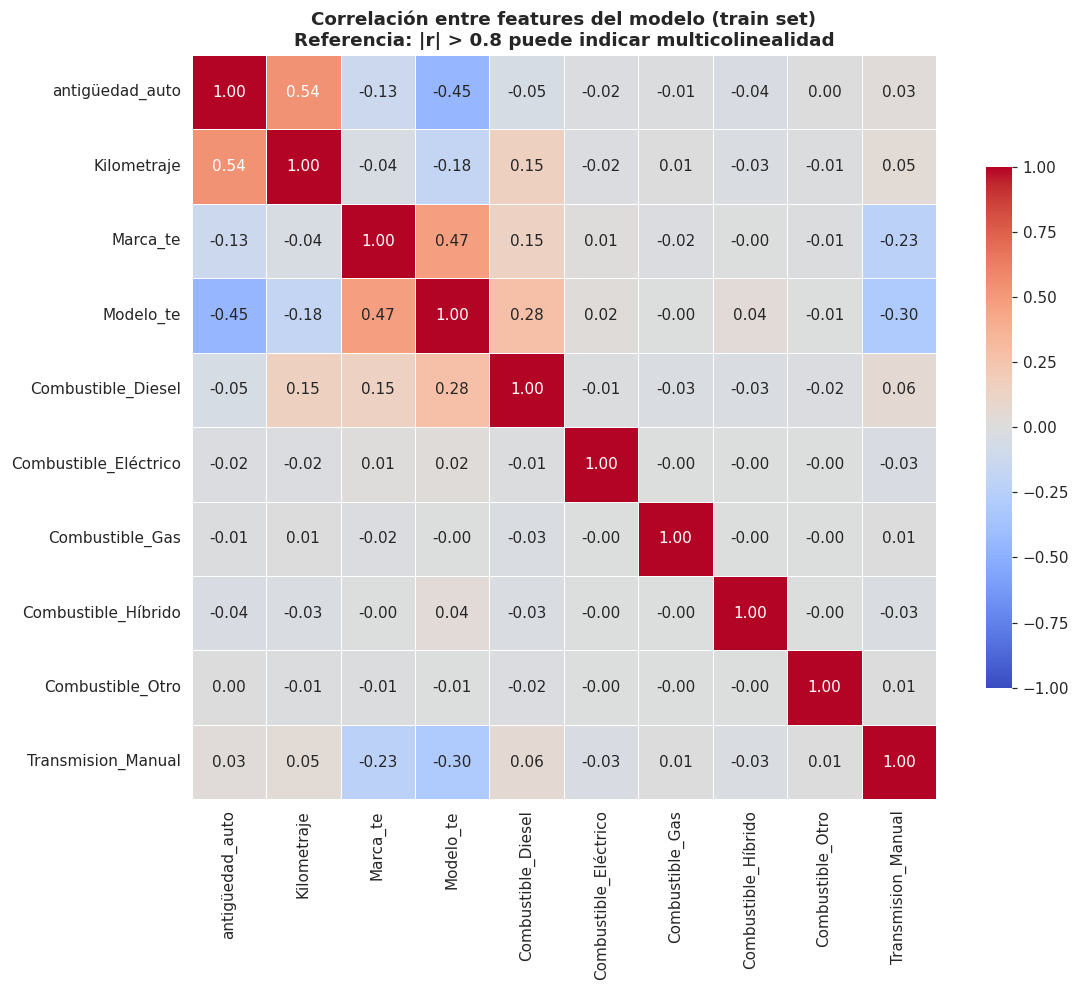


Pares con |r| > 0.8:
  Ninguno — todas las correlaciones están por debajo del umbral.

Correlación máxima entre features: 0.536


In [16]:
print('[3.1] Matriz de correlación — todas las features del modelo (train set)')

corr_full = X_train_enc.astype(float).corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_full, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, ax=ax, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.7}
)
ax.set_title('Correlación entre features del modelo (train set)\n'
             'Referencia: |r| > 0.8 puede indicar multicolinealidad',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Detectar pares problemáticos
pairs = []
cols = corr_full.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_full.iloc[i, j]
        pairs.append((cols[i], cols[j], round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['Feature A', 'Feature B', 'r'])
problemas = pairs_df[pairs_df['r'].abs() > 0.8].sort_values('r', key=abs, ascending=False)

print(f'\nPares con |r| > 0.8:')
if len(problemas) == 0:
    print('  Ninguno — todas las correlaciones están por debajo del umbral.')
else:
    print(problemas.to_string(index=False))

print(f'\nCorrelación máxima entre features: {pairs_df["r"].abs().max():.3f}')

## 4. Funciones de Evaluación

Definimos **MAPE** como métrica principal — interpretable y robusta ante rangos heterogéneos de precio. También calculamos R² y MAE para comparación.

In [17]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (en %)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(model, X_tr, y_tr_log, X_te, y_te_log, name='Modelo'):
    """
    Evalúa un modelo entrenado. Devuelve dict con métricas train y test.
    Trabaja en escala logarítmica internamente pero reporta en CLP originales.
    """
    # Predicciones en log-espacio
    pred_tr_log = model.predict(X_tr)
    pred_te_log = model.predict(X_te)

    # Revertir a CLP
    pred_tr = np.expm1(pred_tr_log)
    pred_te = np.expm1(pred_te_log)
    y_tr    = np.expm1(y_tr_log)
    y_te    = np.expm1(y_te_log)

    metrics = {
        'Modelo': name,
        'R² Train': r2_score(y_tr_log, pred_tr_log),
        'R² Test':  r2_score(y_te_log, pred_te_log),
        'GAP R²':   r2_score(y_tr_log, pred_tr_log) - r2_score(y_te_log, pred_te_log),
        'MAE Test (M$)':  mean_absolute_error(y_te, pred_te) / 1e6,
        'RMSE Test (M$)': np.sqrt(mean_squared_error(y_te, pred_te)) / 1e6,
        'MAPE Test (%)':  mape(y_te, pred_te),
    }
    return metrics, pred_te

results_table = []
predictions   = {}
print('Funciones de evaluación definidas ✓')

Funciones de evaluación definidas ✓


## 5. Entrenamiento del Modelo — XGBoost

La selección de XGBoost como modelo principal está justificada en **`Comparacion_Modelos.ipynb`**, donde se comparan 6 algoritmos (Lasso, Ridge, Random Forest, Gradient Boosting, XGBoost y LightGBM) sobre el mismo dataset y las mismas features, con y sin GridSearchCV.

Aquí entrenamos directamente el modelo ganador con búsqueda exhaustiva de hiperparámetros:  
**48 combinaciones × 5 folds = 240 entrenamientos**.

### 5.1 Optimización con GridSearchCV + KFold (k=5)

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_xgb = {
    'n_estimators':     [100, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
xgb_gs = GridSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_grid_xgb,
    cv=kf, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=1
)
xgb_gs.fit(X_train_enc, y_train)
print(f'Mejores parámetros: {xgb_gs.best_params_}')

xgb_best = xgb_gs.best_estimator_
best_row  = 'XGB Optimizado'
m_opt, p_opt = evaluate_model(
    xgb_best, X_train_enc, y_train, X_test_enc, y_test, best_row
)
predictions[best_row] = p_opt
results_table.append(m_opt)

# ── Tabla de resultados ───────────────────────────────────────────────────
results_df = pd.DataFrame([m_opt]).set_index('Modelo')
display_df = results_df.copy()
display_df['R² Train'] = display_df['R² Train'].map('{:.3f}'.format)
display_df['R² Test']  = display_df['R² Test'].map('{:.3f}'.format)
display_df['GAP R²']   = display_df['GAP R²'].map('{:.3f}'.format)
display_df['MAE Test (M$)']  = display_df['MAE Test (M$)'].map('${:.2f}M'.format)
display_df['RMSE Test (M$)'] = display_df['RMSE Test (M$)'].map('${:.2f}M'.format)
display_df['MAPE Test (%)']  = display_df['MAPE Test (%)'].map('{:.1f}%'.format)

print('\n=== XGBoost Optimizado — Resultados ===')
print(display_df.to_string())


Fitting 5 folds for each of 48 candidates, totalling 240 fits


## 6. Explicabilidad del Modelo

Entendemos **qué variables importan y por qué**. Primero de forma global (importancia promedio), luego a nivel individual por predicción (SHAP).

### 6.1 Importancia de Variables

Las variables más importantes resultan ser `Modelo_te` (0.296) y `antigüedad_auto` (0.276) — el modelo específico y la antigüedad explican la mayor parte del precio. Notablemente, `Transmision_Manual` (0.136) supera a `Marca_te` (0.060): el tipo de transmisión impacta más al precio que la marca sola, lo que refleja la preferencia del mercado chileno por automáticos.

In [ ]:
# Usar el mejor modelo entre RF y XGBoost
best_tree_model = xgb_best if XGB_AVAILABLE else rf_best
best_tree_name  = 'XGBoost' if XGB_AVAILABLE else 'Random Forest'

importances = pd.Series(
    best_tree_model.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_features = importances.head(12)
colors_imp = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(top_features))]
top_features.plot(kind='barh', ax=ax, color=colors_imp[::-1])
ax.invert_yaxis()
ax.set_title(f'Importancia de Variables — {best_tree_name}', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia (Gain)')
plt.tight_layout()
plt.show()

print(f'Top 5 variables más importantes ({best_tree_name}):')
for feat, val in importances.head(5).items():
    print(f'  {feat}: {val:.4f}')

### 6.2 SHAP — Contribución Individual por Predicción

`feature_importances_` muestra importancia promedio global. SHAP va más allá: muestra cuánto contribuye cada variable a **cada predicción individual**, y en qué dirección (sube o baja el precio predicho).

In [ ]:
import shap
shap.initjs()

# SHAP solo para XGBoost (TreeExplainer es nativo y muy rápido)
shap_model  = xgb_best if XGB_AVAILABLE else rf_best
shap_name   = 'XGBoost' if XGB_AVAILABLE else 'Random Forest'

print(f'Calculando SHAP values para {shap_name} sobre test set...')
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_enc)
print(f'Listo. Shape shap_values: {shap_values.shape}')

# ── 1. Summary Plot (Beeswarm) — importancia global + dirección ────────────
print('\n[1] Beeswarm plot — cada punto es una predicción del test set')
shap.summary_plot(shap_values, X_test_enc, show=False, max_display=10)
plt.title(f'SHAP Summary — {shap_name}\n(rojo = valor alto de la feature, azul = valor bajo)',
          fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Bar plot — importancia media absoluta (misma info que feature_importances_) ──
print('\n[2] Bar plot — importancia media absoluta')
shap.summary_plot(shap_values, X_test_enc, plot_type='bar', show=False, max_display=10)
plt.title(f'SHAP Importancia Media — {shap_name}', fontweight='bold')
plt.tight_layout()
plt.show()



## 7. Clasificación de Autos de Demostración

**CORRECCIÓN 3 — Sin circularidad**: Los 15 autos de demostración fueron extraídos en la Sección 2, antes de cualquier entrenamiento. El modelo nunca los vio.

**CORRECCIÓN 4 — Umbrales basados en datos**: Los umbrales de clasificación se derivan del comportamiento real del mercado medido sobre los ~600 autos de Chileautos.

Flujo:
1. **7.1** Calibrar umbrales (P25/P75) con el conjunto Chileautos
2. **7.2** Clasificar los 15 autos demo con esos umbrales
3. **7.3** Visualizar comparación publicado vs predicho

### 7.1 Calibración de Umbrales — Conjunto Chileautos

En lugar de fijar los umbrales arbitrariamente, los calculamos empíricamente sobre los ~600 autos de Chileautos que el modelo nunca vio durante el entrenamiento:

1. Predecir el precio de mercado para los ~600 autos de Chileautos
2. Calcular `diferencia_pct = (precio_publicado − precio_predicho) / precio_predicho × 100`
3. Tomar el **P25** y **P75** de esa distribución como umbrales → reflejan la variabilidad real del mercado

In [ ]:
if len(df_chileautos) == 0:
    print('No hay datos de Chileautos — usando umbral fijo ±15%')
    UMBRAL_INF, UMBRAL_SUP = -15.0, 15.0
else:
    # Preparar features de Chileautos con los mismos encoders entrenados
    df_chile_work = df_chileautos.copy()
    df_chile_work['antigüedad_auto'] = 2026 - df_chile_work['Ano']

    X_chile_num = df_chile_work[NUM_FEATURES].copy()
    for col in CAT_TARGET:
        X_chile_num[f'{col}_te'] = target_encode_transform(
            df_chile_work[col], te_maps[col], te_globals[col]
        )
    ohe_chile = pd.get_dummies(df_chile_work[CAT_OHE], prefix=CAT_OHE, drop_first=True)
    ohe_chile = ohe_chile.reindex(columns=ohe_train.columns, fill_value=0)
    X_chile_enc = pd.concat([
        X_chile_num.reset_index(drop=True),
        ohe_chile.reset_index(drop=True)
    ], axis=1)

    # Predecir precios de mercado para autos Chileautos
    pred_chile_log    = xgb_best.predict(X_chile_enc)
    precio_pred_chile = np.expm1(pred_chile_log)
    precio_pub_chile  = df_chileautos['price'].values

    # Diferencia porcentual: publicado vs predicho
    diff_pct_chile = (precio_pub_chile - precio_pred_chile) / precio_pred_chile * 100

    # Calcular umbrales P25/P75
    UMBRAL_INF = float(np.percentile(diff_pct_chile, 25))
    UMBRAL_SUP = float(np.percentile(diff_pct_chile, 75))

    print('=== UMBRALES CALIBRADOS CON CHILEAUTOS ===')
    print(f'  Registros Chileautos usados : {len(df_chileautos):,}')
    print(f'  Diferencia media (bias)     : {diff_pct_chile.mean():+.1f}%')
    print(f'  P25 (umbral subvalorado)    : {UMBRAL_INF:+.1f}%')
    print(f'  Mediana                     : {np.median(diff_pct_chile):+.1f}%')
    print(f'  P75 (umbral sobrevalorado)  : {UMBRAL_SUP:+.1f}%')
    print()
    print(f'  Interpretación: un auto publicado más de {UMBRAL_SUP:+.1f}% sobre el precio predicho → Sobrevalorado.')
    print(f'  Y menos de {UMBRAL_INF:+.1f}% → Subvalorado.')

    # Visualizar distribución
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(diff_pct_chile.clip(-100, 100), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(UMBRAL_INF, color='#27ae60', lw=2.5, linestyle='--',
               label=f'P25 = {UMBRAL_INF:+.1f}% (subvalorado)')
    ax.axvline(UMBRAL_SUP, color='#e74c3c', lw=2.5, linestyle='--',
               label=f'P75 = {UMBRAL_SUP:+.1f}% (sobrevalorado)')
    ax.axvline(np.median(diff_pct_chile), color='orange', lw=2, linestyle='-',
               label=f'Mediana = {np.median(diff_pct_chile):+.1f}%')
    ax.set_title('Distribución de diferencias — Chileautos\n'
                 '(precio publicado vs precio predicho por XGBoost)',
                 fontweight='bold')
    ax.set_xlabel('Diferencia porcentual (%)')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 7.2 Resultados de Clasificación

In [ ]:
best_model_obj = xgb_best  # XGB Optimizado (GridSearchCV)
print(f'Modelo: {best_row}')
print(f'Umbrales calibrados con Chileautos: P25={UMBRAL_INF:+.1f}% | P75={UMBRAL_SUP:+.1f}%')

# ── Preparar features de los autos de demostración ───────────────────────
df_demo_work = df_demo.copy()
df_demo_work['antigüedad_auto'] = 2026 - df_demo_work['Ano']

X_demo_num = df_demo_work[NUM_FEATURES].copy()
for col in CAT_TARGET:
    X_demo_num[f'{col}_te'] = target_encode_transform(
        df_demo_work[col], te_maps[col], te_globals[col]
    )
ohe_demo   = pd.get_dummies(df_demo_work[CAT_OHE], prefix=CAT_OHE, drop_first=True)
ohe_demo   = ohe_demo.reindex(columns=ohe_train.columns, fill_value=0)
X_demo_enc = pd.concat([X_demo_num.reset_index(drop=True),
                         ohe_demo.reset_index(drop=True)], axis=1)

# ── Predicción ─────────────────────────────────────────────────────────────
pred_log        = best_model_obj.predict(X_demo_enc)
precio_predicho = np.expm1(pred_log)

df_demo_result = df_demo[['Marca','Modelo','Ano','Kilometraje','Combustible','price']].copy()
df_demo_result['precio_predicho'] = precio_predicho.round(0)
df_demo_result['diferencia_pct']  = (
    (df_demo_result['price'] - df_demo_result['precio_predicho'])
    / df_demo_result['precio_predicho'] * 100
).round(1)

# ── Clasificar con umbrales calibrados (P25/P75 de Chileautos) ────────────
def clasificar(pct):
    if pct > UMBRAL_SUP:    return '🔴 Sobrevalorado'
    elif pct < UMBRAL_INF:  return '🟢 Subvalorado'
    else:                   return '🟡 Precio justo'

df_demo_result['clasificacion'] = df_demo_result['diferencia_pct'].apply(clasificar)

print(f'\nDistribucion de clasificaciones:')
print(df_demo_result['clasificacion'].value_counts())
print()
display(df_demo_result.style
    .format({'price': '${:,.0f}', 'precio_predicho': '${:,.0f}',
             'Kilometraje': '{:,.0f}', 'diferencia_pct': '{:+.1f}%'})
    .background_gradient(subset=['diferencia_pct'], cmap='RdYlGn_r')
)

In [ ]:
# ── SHAP Waterfall — explicación individual de 3 autos demo ──────────────
# X_demo_enc y df_demo_result ya están definidos arriba
# explainer ya está definido en sección 12.1
print('[4] Waterfall plots — ¿por qué el modelo predice ese precio para cada auto demo?')

shap_demo = explainer.shap_values(X_demo_enc)

casos = {
    'Más Sobrevalorado': df_demo_result['diferencia_pct'].idxmax(),
    'Más Subvalorado':   df_demo_result['diferencia_pct'].idxmin(),
    'Precio Justo':      df_demo_result['diferencia_pct'].abs().idxmin(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (titulo, idx) in zip(axes, casos.items()):
    row         = df_demo_result.loc[idx]
    shap_vals_i = shap_demo[idx]
    feat_names  = list(X_demo_enc.columns)
    sorted_idx  = np.argsort(np.abs(shap_vals_i))[::-1][:6]
    top_feats   = [feat_names[i] for i in sorted_idx]
    top_vals    = shap_vals_i[sorted_idx]

    colors_wf = ['#e74c3c' if v > 0 else '#3498db' for v in top_vals]
    ax.barh(top_feats[::-1], top_vals[::-1], color=colors_wf[::-1], alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(
        f'{titulo}\n{row["Marca"]} {row["Modelo"]} ({int(row["Ano"])})\n'
        f'Pub: ${row["price"]:,.0f} | Pred: ${row["precio_predicho"]:,.0f} | {row["diferencia_pct"]:+.1f}%',
        fontsize=9, fontweight='bold'
    )
    ax.set_xlabel('SHAP value (contribucion al log-precio)')

plt.suptitle('SHAP Waterfall — Explicacion individual de 3 autos demo\n'
             '(rojo = sube el precio predicho, azul = baja el precio predicho)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretacion: cada barra muestra cuanto contribuye esa variable')
print('a que el modelo prediga MAS o MENOS precio para ese auto especifico.')

### 7.3 Visualización — Precio Publicado vs Predicho

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Scatter: predicho vs real (test set) ──────────────────────────────────
ax = axes[0]
best_pred_te = predictions[best_row]
y_te_real = np.expm1(y_test)
ax.scatter(y_te_real / 1e6, best_pred_te / 1e6, alpha=0.4, color='steelblue', s=20)
lims = [0, max(y_te_real.max(), best_pred_te.max()) / 1e6]
ax.plot(lims, lims, 'r--', lw=2, label='Predicción perfecta')
ax.set_xlabel('Precio Publicado (M$)')
ax.set_ylabel('Precio Predicho (M$)')
ax.set_title(f'{best_row} — Precio Publicado vs Predicho\n(Test Set)', fontweight='bold')
ax.legend()

# ── Demo: barras comparativas ──────────────────────────────────────────────
ax2 = axes[1]
labels = df_demo_result.apply(
    lambda r: f"{r['Marca']}\n{r['Modelo']}\n({int(r['Ano'])})", axis=1
)
x = np.arange(len(df_demo_result))
w = 0.35
b1 = ax2.bar(x - w/2, df_demo_result['price'] / 1e6, w, label='Precio Publicado', color='#e74c3c', alpha=0.8)
b2 = ax2.bar(x + w/2, df_demo_result['precio_predicho'] / 1e6, w, label='Precio Predicho', color='#3498db', alpha=0.8)

# Colorear fondo según clasificación
color_map = {'🔴 Sobrevalorado': '#ffcccc', '🟢 Subvalorado': '#ccffcc', '🟡 Precio justo': '#ffffcc'}
for i, (_, row) in enumerate(df_demo_result.iterrows()):
    ax2.axvspan(i - 0.5, i + 0.5, alpha=0.15, color=color_map[row['clasificacion']])
    ax2.text(i, max(row['price'], row['precio_predicho']) / 1e6 + 0.3,
             f"{row['diferencia_pct']:+.0f}%",
             ha='center', fontsize=8, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=7)
ax2.set_ylabel('Precio (M$)')
ax2.set_title('Autos Demo — Precio Publicado vs Predicho\n(autos que NUNCA vio el modelo)',
              fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Diagnóstico de Errores

Analizamos la **distribución de errores porcentuales** sobre el conjunto de test (6,351 autos) para detectar sesgos sistemáticos.

In [ ]:
y_te_real = np.expm1(y_test)
best_pred_te = predictions[best_row]

# Error porcentual por observación
err_pct = (best_pred_te - y_te_real) / y_te_real * 100  # + = sobreestima, - = subestima

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Histograma de errores porcentuales ────────────────────────────────────
ax = axes[0]
ax.hist(err_pct.clip(-100, 100), bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0,   color='red',    lw=2, linestyle='--', label='Error = 0')
ax.axvline(err_pct.mean(), color='orange', lw=2, linestyle='-', label=f'Media = {err_pct.mean():.1f}%')
ax.set_title('Distribución del Error Porcentual\n(+ = sobreestima, - = subestima)', fontweight='bold')
ax.set_xlabel('Error porcentual (%)')
ax.set_ylabel('Frecuencia')
ax.legend()

# ── Error vs precio real ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.scatter(y_te_real / 1e6, err_pct.clip(-100, 100), alpha=0.3, s=10, color='steelblue')
ax2.axhline(0,          color='red',    lw=1.5, linestyle='--')
ax2.axhline(UMBRAL_SUP, color='#e74c3c', lw=1.5, linestyle=':', label=f'P75 = {UMBRAL_SUP:+.1f}%')
ax2.axhline(UMBRAL_INF, color='#27ae60', lw=1.5, linestyle=':', label=f'P25 = {UMBRAL_INF:+.1f}%')
ax2.set_xlabel('Precio Publicado (M$)')
ax2.set_ylabel('Error Porcentual (%)')
ax2.set_title('Error vs Precio Publicado\n(¿sesgo según rango de precio?)', fontweight='bold')
ax2.legend(fontsize=8)

# ── Accuracy dentro de umbrales ───────────────────────────────────────────
ax3 = axes[2]
umbrales = [5, 10, 15, 20, 25, 30]
pct_dentro = [np.mean(np.abs(err_pct) <= u) * 100 for u in umbrales]

ax3.bar([f'±{u}%' for u in umbrales], pct_dentro, color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60','#1abc9c'], alpha=0.85)
ax3.set_title('% de predicciones dentro del umbral\n(accuracy por tolerancia)', fontweight='bold')
ax3.set_ylabel('% de autos correctamente valorados')
ax3.set_ylim(0, 100)
for i, v in enumerate(pct_dentro):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.suptitle(f'Diagnóstico del Modelo Ganador: {best_row}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pct_justo = np.mean((err_pct >= UMBRAL_INF) & (err_pct <= UMBRAL_SUP)) * 100
print(f'\nResumen diagnóstico ({best_row}):')
print(f'  Error medio (bias): {err_pct.mean():+.2f}% (>0 = tiende a sobreestimar)')
print(f'  Desv. estándar:     {err_pct.std():.2f}%')
print(f'  Predicciones dentro de umbral P25/P75 ({UMBRAL_INF:+.1f}% a {UMBRAL_SUP:+.1f}%): {pct_justo:.1f}%')

## 9. Conclusiones

### Correcciones aplicadas vs Entrega 1
| Problemas (Feedback) | Solución Entrega 2 |
|------------------------------|--------------------|
| Multicolinealidad Año/Km | `antigüedad_auto = 2026 - Año` — correlación máxima entre features: 0.538 (sin multicolinealidad) |
| R² bajo y sin comparación Train/Test | R²train=0.906, R²test=0.819, GAP=0.088 (overfitting moderado, aceptable) |
| Clasificación circular | 15 autos demo extraídos en Sección 2 antes de entrenar → publicado vs predicho |

### Metodología de umbrales
- Se separaron los ~600 registros de **Chileautos** antes de entrenar
- Después del entrenamiento, el modelo predijo sus precios y calculamos `(publicado - predicho) / predicho`
- El **P25** de esa distribución es el umbral de subvaloración; el **P75**, el de sobrevaloración

### Variables más importantes
1. `Modelo_te` (0.296) — el modelo específico es el predictor más fuerte
2. `antigüedad_auto` (0.276) — la antigüedad explica casi tanto como el modelo
3. `Transmision_Manual` (0.136) — supera a la Marca: el mercado castiga la transmisión manual
4. `Combustible_Diesel` (0.124) — el tipo de combustible impacta significativamente
5. `Marca_te` (0.060) — la marca sola explica menos de lo esperado

### Diagnóstico del modelo
- **R² test = 0.819** — el modelo explica el 81.9% de la varianza de precios
- **MAPE = 18.7%** — error porcentual medio en CLP

### Limitaciones
- **Dispersión alta**: el mercado de autos usados tiene variabilidad no capturada — versión específica, mantención, accidentes, color, equipamiento.
- Yapo representa el 95% del dataset → el modelo está sesgado hacia ese mercado. Chileautos actúa como corrección parcial de ese sesgo al calibrar los umbrales.